Notebook for composite Bayesian Optimization on Tilt and Thickness<br>
Written by Dasol Yoon and Poompol Buathong<br>
Last edited on Jan 6, 2025

In [1]:
import sys
print(sys.executable)
print(sys.version)
print(sys.version_info)

/opt/miniconda3/envs/BOttV02/bin/python
3.13.1 | packaged by conda-forge | (main, Dec  5 2024, 21:09:18) [Clang 18.1.8 ]
sys.version_info(major=3, minor=13, micro=1, releaselevel='final', serial=0)


In [2]:
%matplotlib inline

In [3]:
import torch
import random
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_model
from botorch.acquisition.objective import GenericMCObjective
from botorch.models.gp_regression import FixedNoiseGP, SingleTaskGP
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf

import math
import numpy as np
import matplotlib.pyplot as plt

# use a GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double

In [4]:
import scipy.ndimage
import glob
from datetime import datetime
import warnings

In [5]:
#change the file path to where the dataset is/will be stored

#fpath = 'D:/Lab/Experiments/20231100-TiltML/data/data/1/simulation/'
fpath = '/Users/dash/Documents/Cornell/BOtt/simulation/'

In [6]:
def load(x):
    #----variables----
    #x: [[thickness [angstrom], tilt]]
    #returns pre-simulated PACBED image.
    thickness=x[0,0]
    tilt = x[0,1]   
    
    tag = '/{:04d}'.format(int(thickness))
    imgPath = glob.glob(fpath+'Tilt_{}_Azimuth_0_Conv_Angle_25.0/'.format(int(tilt))
                        +tag[:4]+'*.tif')[0] #1st in list
    try: #load PACBED from the directory
        pacbed = plt.imread(imgPath)
        pacbed = pacbed[25:-25,25:-25].astype(np.float64) #added 20241112. bad simulation. crop zeroes.
    except: #handle exceptions
        print('no such file: ' +imgPath)

    #pacbed_sqrt = np.sqrt(pacbed) #added 20241017
    #pacbed_norm = pacbed_sqrt/np.mean(pacbed_sqrt) #added 20241017; "standardize" the data...? Isn't it redundant with the normalization?
    pacbed_norm = (pacbed-np.min(pacbed))/(np.max(pacbed)-np.min(pacbed)) #normalize 0-1
    #pacbed_smol = scipy.ndimage.zoom(pacbed_norm.astype(np.float64),20/pacbed_norm.shape[0],order=1) #Nov12: comment out
    #pacbed_norm = (pacbed_smol-np.min(pacbed_smol))/(np.max(pacbed_smol)-np.min(pacbed_smol)) #normalize 0-1 #Nov12: comment out
    

    #unicode for angstrom
    #print('thickness: {} \u212B  || shape: {} || filename: '.format(x, pacbed_norm.shape)+imgPath[90:])
    
    return torch.Tensor(pacbed_norm)#.reshape(-1) #PB: change to tensor

In [7]:
# This is the correct value of the parameter
x_real = np.array([[250,4]])

# Get the PACBED at the thickness of x_real
y_raw = load(x_real) #[simulate(x_val) for x_val in x_obs]

# Upper and lower bounds for our search
lower = 10
upper = 500

In [8]:
#TODO: use thinner one for test case
#PB changed to tensor
#TODO: Currently hard coded for the patch size. Need to modify later
def intoPatches(y_pred_raw):
    arr = torch.Tensor([]);
    for i in range(3):
        for j in range(3):
            patch = torch.mean(y_pred_raw[...,50*i:50*(i+1),...,50*j:50*(j+1)]).unsqueeze(-1)
            arr = torch.cat((arr,patch*1e1),dim=-1)
    return arr #, rss*100)) #unpack part #

In [9]:
y_patC = intoPatches(y_raw) # compute reference values for patches

In [10]:
def pixelSSE(y_pred_raw):
    err = y_pred_raw-y_raw # #one image y_obs: image I want to measure
    return np.power(err,2).sum().unsqueeze(-1)

In [11]:
def patchesSSE(pat): #patches of y and RSS in 10 variables
    return (pat-y_patC).pow(2).sum().unsqueeze(-1)

In [12]:
def computeY(y_pred_raw):
    pat = intoPatches(y_pred_raw)
    patchTerm = patchesSSE(pat)
    pixelTerm = pixelSSE(y_pred_raw)
    return torch.cat((pat,pixelTerm-patchTerm),dim=-1).unsqueeze(0) #y_pred

In [13]:
y_obsC = computeY(y_raw) # compute reference values

/var/folders/6g/x0m1vg9s7dzb28pr980bgk_w0000gn/T/ipykernel_35101/3022455256.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.power(err,2).sum().unsqueeze(-1)


In [14]:
def computeObjectiveC(y_pred):
    return -((y_pred[...,:9]-y_obsC[...,:9]).pow(2).sum()+y_pred[...,9]).unsqueeze(-1)
    # return - (np.power( y_pred[:9]-y_obsC[:9], 2).sum() + y_pred[9] ) #pixelTerm - patchTerm #question: isn't it just the pixelTerm?

In [15]:
def add_dataC(new_x, x=None, y=None, obj=None):
    
    # Convert to a numpy array if it is a tensor
    # if type(new_x) is torch.Tensor:
    #     new_x = new_x.numpy()
        
    # Convert new_x to the right dimension, which is an array of dimension 1 
    # if np.isscalar(new_x):
    #     new_x = [new_x]
    # elif len(np.shape(new_x))==2:
    #     new_x = new_x.squeeze(1)

    if x is None:
        x = torch.tensor([])
    if y is None:
        y = torch.tensor([])
    if obj is None:
        obj = torch.tensor([])
    new_y = computeY(load(new_x)) # y is a tensor
    new_obj = computeObjectiveC(new_y) # this is our objective

    # x and obj are both 2D tensors that are nx1
    # y is a 3D tensor that is nx20x20 -> 12
    x = torch.cat((x, new_x),dim=0)
    y = torch.cat((y, new_y),dim=0)
    obj = torch.cat((obj, torch.tensor(new_obj.clone().detach())),dim=0)
    return x.to(torch.double), y.to(torch.double), obj.to(torch.double)

In [16]:
from botorch.sampling.normal import IIDNormalSampler #import package
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.utils.sampling import draw_sobol_samples

In [17]:
# Plot the posterior for a single simulation output y
def plot_posterior_composite(ax, model, gridX1, gridX2, train_x, train_y, legend=True):
    with torch.no_grad(): # no need for gradients
        test_x = torch.stack([gridX1.flatten(),gridX2.flatten()],dim=1)
        # compute posterior
        posterior_x_domain = model.posterior(test_x)

        inner_sample = IIDNormalSampler(sample_shape=torch.Size([2048])) #define based sample
        samples = inner_sample(posterior_x_domain) # do the sample
        
        samples_obj = g(samples) #DY: make it objective only
        
        samplesmedian,_ = samples_obj.median(dim=0) # compute median (you can use mean)
        samples025 = samples_obj.quantile(q=0.25,dim=0) #compute quantile
        samples0975=samples_obj.quantile(q=0.975,dim=0) #compute quantile
         
        # Plot training points as black stars
        ax.plot(train_x[:, 0].cpu().numpy(), 
                train_x[:, 1].cpu().numpy(), 
                g(train_y).cpu().numpy().squeeze(),'k*')

        # Plot posterior means as a surface 
        post = ax.plot_surface(gridX1, gridX2, 
                               samplesmedian.detach().reshape(gridx1.shape), 
                               cmap='autumn_r', alpha=0.5)
        
        # Upper and lower bounds
        ax.plot_wireframe(gridX1,gridX2,
                          samples025.detach().reshape(gridx1.shape),
                          alpha=0.5) #lw=0.5, rstride=2, cstride=2,
        ax.plot_wireframe(gridX1,gridX2,
                          samples0975.detach().reshape(gridx1.shape),alpha=0.5)
        ax.set_xlabel('thickness');ax.set_ylabel('tilt')
        
    if legend:
        plt.legend(['Observed Data', 'Mean', 'Credible Interval'])

In [19]:
def generate_initial_data(n_initial_points):    
    new_x = (
            draw_sobol_samples(
                bounds=torch.tensor([[lower,1], [upper,10]]).to(torch.double),
                n=n_initial_points,
                q=1,
            )
        )
    for i in range(n_initial_points):
        if i == 0:
            x,y,obj = add_dataC(new_x[i,...])
        else:
            x,y,obj = add_dataC(new_x[i,...],x,y,obj)
    return x,y,obj

Test Fit model and optimizing EI

In [20]:
from botorch.models.transforms import Standardize
from botorch.models.transforms.input import Normalize

In [18]:
#x_domain = torch.linspace(lower, upper, 1000).unsqueeze(-1).to(torch.double)
def plot_model_EI(ax, gridX1, gridX2, model,acqf,iter_no):
    test_x = torch.stack([gridX1.flatten(),gridX2.flatten()],dim=1)
    
    #fig,axis = plt.subplots(6, 2, figsize=(10, 15), gridspec_kw={'hspace': 0.5, 'wspace': 0.3})
    #x_domain = torch.linspace(lower, upper, 1000).unsqueeze(-1).to(torch.double)

    post_at_x_domain = model.posterior(test_x)
    mean_at_x_domain = post_at_x_domain.mean
    std_at_x_domain = torch.sqrt(post_at_x_domain.variance)
    lo_at_x_domain = mean_at_x_domain-1.96*std_at_x_domain
    up_at_x_domain = mean_at_x_domain+1.96*std_at_x_domain
    # count_idx = 0
    # for i in range(5):
    #     for j in range(2):
    #         axis[i,j].set_title(plot_name[count_idx])
    #         axis[i,j].plot(x,y[...,count_idx].detach().numpy(),marker='*', linestyle='none', markersize=10, color='black')
    #         axis[i,j].plot(x_domain,mean_at_x_domain[...,count_idx].detach().numpy(),color='blue',linewidth=2,label='Prediction')
    #         axis[i,j].fill_between(x_domain.squeeze(-1),lo_at_x_domain[...,count_idx].detach().numpy(),up_at_x_domain[...,count_idx].detach().numpy(),alpha=0.2,color='blue',label='Uncertainty')
    #         axis[i,j].legend()
    #         count_idx+=1
    
    # inner_sample = IIDNormalSampler(sample_shape=torch.Size([2048])) #define based sample
    # samples = inner_sample(post_at_x_domain) # do the sample
    # samples_obj = g(samples)
    # samplesmedian,_ = samples_obj.median(dim=0)
    # samples025 = samples_obj.quantile(q=0.25,dim=0)
    # samples0975 = samples_obj.quantile(q=0.975,dim=0)
    # axis[5,0].set_title(plot_name[count_idx])
    # axis[5,0].plot(x,g(y).squeeze(0).detach().numpy(),marker='*', linestyle='none', markersize=10, color='black')
    # axis[5,0].plot(x_domain,samplesmedian.detach().numpy(),color='red',linewidth=2,label='Prediction')
    # axis[5,0].fill_between(x_domain.squeeze(-1),samples025.detach().numpy(),samples0975.detach().numpy(),alpha=0.2,color='red',label='Uncertainty')
    # axis[5,0].legend()
    # count_idx+=1
    
    acqf_val = acqf(x_domain.unsqueeze(-1))
    axis[5,1].set_title(plot_name[count_idx])
    axis[5,1].plot(x_domain,acqf_val.detach().numpy(),color='green',label='EI')
    axis[5,1].plot(new_point.detach().numpy(),new_point_EI.detach().numpy(),marker='*',linestyle='none', markersize=10, color='yellow',label='Candidate')
    axis[5,1].legend()
    plt.suptitle(f"Iteration {iter_no}", fontsize=14, y=0.91)  # Reduce `y` to bring closer
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust subplot grid to fit universal title
    plt.show()

In [21]:
def plotEI(ax,gridX1,gridX2, ei, new_pt):
    test_x = torch.stack([gridX1.flatten(),gridX2.flatten()],dim=1)
    acq = ei.forward(test_x.unsqueeze(1))
    acqValues = acq.detach().numpy().reshape(gridX1.shape)
    
    # Contour plot of EI over the 2D input space
    ct = ax.contourf(gridX1.numpy(), gridX2.numpy(), 
                     acqValues, cmap='viridis')
    plt.colorbar(ct)
    
    # Mark the new point found by the optimizer
    ax.plot(new_pt[0,0].numpy(), new_pt[0,1].numpy(), 'ro')
    
    ax.set_title('Expected Improvement (EI)')
    ax.set_xlabel('Thickness'); ax.set_ylabel('Tilt');

/var/folders/6g/x0m1vg9s7dzb28pr980bgk_w0000gn/T/ipykernel_35101/3022455256.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.power(err,2).sum().unsqueeze(-1)
/var/folders/6g/x0m1vg9s7dzb28pr980bgk_w0000gn/T/ipykernel_35101/3042752386.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obj = torch.cat((obj, torch.tensor(new_obj.clone().detach())),dim=0)
/opt/miniconda3/envs/BOttV02/lib/python3.13/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1733623092662/work/aten/src/ATen/native/TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-define

Best value (thickness,tilt,obj) found: 225.2635274734348 , 6.577906293794513
Best value found: -44.025482177734375
iteration #0. best_obj: -44.02548134158371
new_point_EI val: 24.143


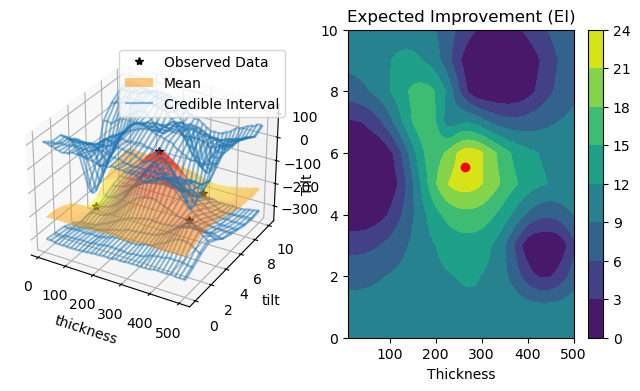

Iteration 0, measuring at x=263.21636962890625,5.550570964813232
Best values (thickness,tilt,obj) found: 263.21636962890625, 5.550570964813232, -12.986251831054688
iteration #1. best_obj: -12.9862517760576
new_point_EI val: 15.487


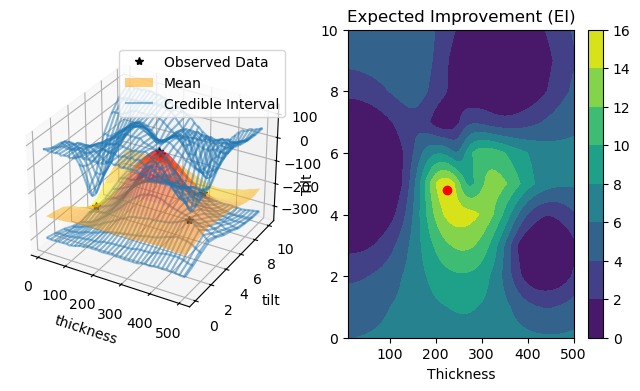

Iteration 1, measuring at x=224.41445922851562,4.81113862991333
Best values (thickness,tilt,obj) found: 224.41445922851562, 4.81113862991333, -6.644861698150635
iteration #2. best_obj: -6.644861586943591
new_point_EI val: 14.045


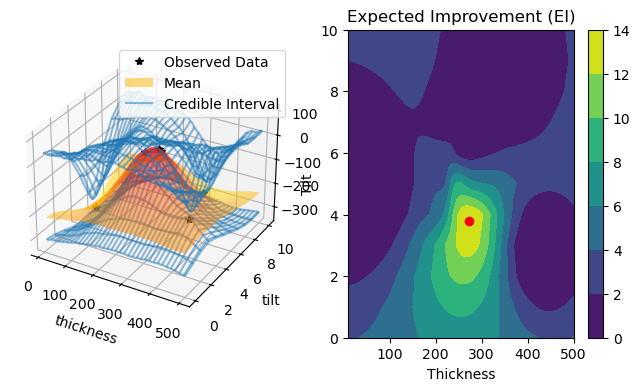

Iteration 2, measuring at x=273.24127197265625,3.7952303886413574
Best values (thickness,tilt,obj) found: 224.41445922851562, 4.81113862991333, -6.644861698150635
iteration #3. best_obj: -6.644861586943591
new_point_EI val: 9.0834


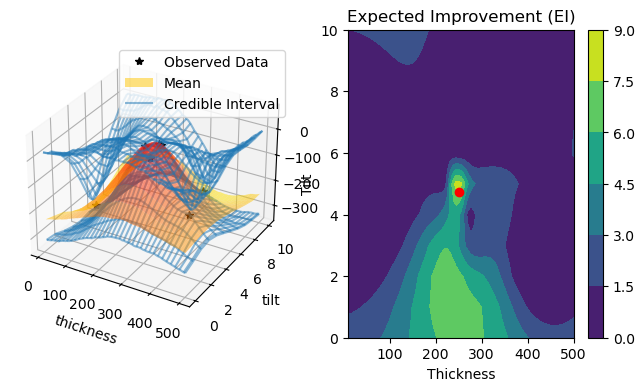

Iteration 3, measuring at x=251.66123962402344,4.727825164794922
Best values (thickness,tilt,obj) found: 251.66123962402344, 4.727825164794922, -0.0
iteration #4. best_obj: -0.0
new_point_EI val: 4.207


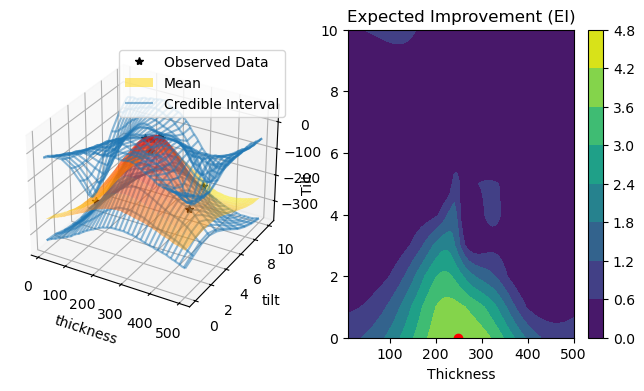

Iteration 4, measuring at x=249.29299926757812,0.0
Best values (thickness,tilt,obj) found: 251.66123962402344, 4.727825164794922, -0.0
Time elapsed (hh:mm:ss.ms):  0:00:52.759078 


In [22]:
start = datetime.now()
seed = 111
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)
n_initial_points = 4
n_BO_points = 5#20

# Generate initial data: several datapoints at random
# Each one of them will be uniform between 0 and 3
x,y,obj = generate_initial_data(n_initial_points=n_initial_points)
g = GenericMCObjective(objective=lambda _y,**kwargs: - (torch.sum( (_y[...,:9]-torch.tensor(y_obsC[...,:9].clone().detach()).unsqueeze(0)).pow(2) , dim=-1)+_y[...,9]) )
best = [obj.max().detach().item()] # This will store the best value
best_x_idx = obj.argmax()
print('Best value (thickness,tilt,obj) found: {} , {}'.format(x[best_x_idx,0].item(),
                                                              x[best_x_idx,1].item(),obj[best_x_idx]))
print('Best value found: {}'.format(best[-1]))

gridx1,gridx2 = torch.meshgrid(torch.linspace(lower,upper,101),torch.linspace(0,10,11))
        
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    #warnings.filterwarnings('ignore',category=InputDataWarning)
    for i in range(n_BO_points):
    
        # Fit the model
        noise = torch.ones_like(y) * 0.0001
        model = FixedNoiseGP(x, y, noise,outcome_transform=Standardize(m=10),input_transform=Normalize(d=2)) # GP is on y, not the objective
        # model = SingleTaskGP(x, y) # GP is on y, not the objective
        fit_gpytorch_model(ExactMarginalLogLikelihood(model.likelihood, model))
        ###question
        #g = GenericMCObjective(objective=lambda _y: -(_y[:,:9]-torch.tensor(y_obsC[:9])).pow(2).mean(dim=-1) +_y[:,9] )
        #... for the batch. Whatever dimension in front then the dimension that i specify.
        #From 100 initial points, chooses 50 initial best points for the gradient descent
        best_obj = g(y).max() # same as -obj.min()
        print("iteration #{}. best_obj: {}".format(i,best_obj))
        sampler = SobolQMCNormalSampler(1024)
        EI = qExpectedImprovement(model=model, best_f=best_obj, objective=g,sampler=sampler)
        new_point, new_point_EI = optimize_acqf(
            acq_function=EI,
            bounds=torch.tensor([[lower,0], [upper,10]]).float(),
            q=1,
            num_restarts=50,
            raw_samples=100,
        )
        print(f"new_point_EI val: {new_point_EI:.5}")
            
        # # Plot the posterior and the EI
        # plot_model_EI(model=model, acqf=EI,iter_no=i+1)
        f, (ax1,ax2) = plt.subplots(1, 2, figsize=(8, 4))
        
        # Plot the posterior
        ax1.axis('off')
        ax1 = plt.subplot(121, projection='3d') #row, col, index
        plot_posterior_composite(ax1,model,gridx1,gridx2,x,y)
        
        # Plot EI
        plotEI(ax2,gridx1,gridx2,EI,new_point)
        plt.show()
        print('Iteration {}, measuring at x={},{}'.format(i,new_point[0,0].item(),new_point[0,1].item()) )
        
        # print('Iteration {}, measuring at x={}'.format(i+1,new_point.item()) )
        x,y,obj = add_dataC(new_point,x,y,obj)
        best.append(obj.max().item())
        best_x_idx = obj.argmax()
        print('Best values (thickness,tilt,obj) found: {}, {}, {}'.format(x[best_x_idx,0].item(),x[best_x_idx,1].item(),obj.max()))
# torch.cuda.synchronize()
end = datetime.now()
print('Time elapsed (hh:mm:ss.ms):  {} '.format(end-start))

In [23]:
x

tensor([[ 27.2631,   5.3129],
        [330.3008,   8.5818],
        [435.2020,   2.8168],
        [225.2635,   6.5779],
        [263.2164,   5.5506],
        [224.4145,   4.8111],
        [273.2413,   3.7952],
        [251.6612,   4.7278],
        [249.2930,   0.0000]], dtype=torch.float64)

In [33]:
best = np.array(best)
#xArr = np.array(x)
np.savez('20241210-composite_initial4_tilt_oneIt.npz',best=best,x=x,obj=obj)

Text(0.5, 1.0, 'Ground truth: [[250   4]]. Ended with: 251 and 4 at iteration #7')

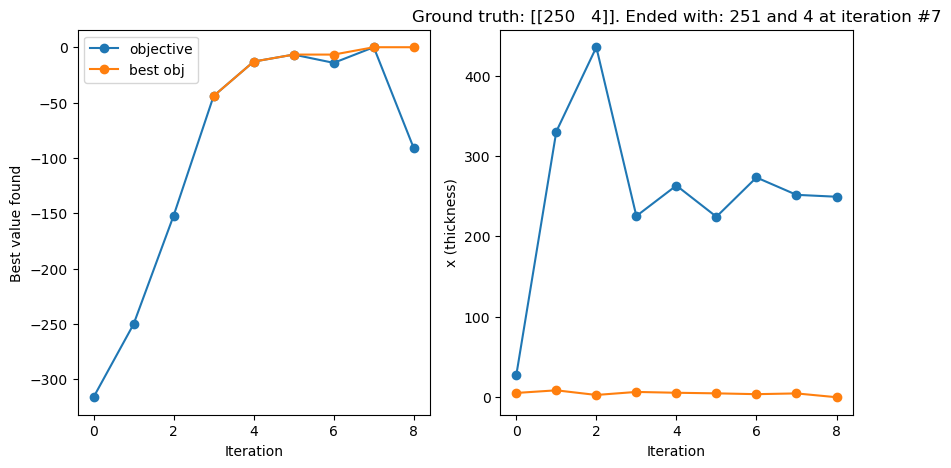

In [38]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(obj.numpy(),'o-',label='objective')
ax[0].plot(np.arange(len(best))+n_initial_points-1,best,'o-',label='best obj')
ax[0].set_xlabel('Iteration')
ax[0].set_ylabel('Best value found')
#ax[0].set_yscale("log", base=10)
#plt.ylim(1e-3,1)
ax[0].legend()

ax[1].plot(x,'o-')
ax[1].set_xlabel('Iteration')
ax[1].set_ylabel('x (thickness)')
ax[1].set_title('Ground truth: {}. Ended with: {} and '
                '{} at iteration #{}'.format(x_real,
                                             int(x[best_x_idx][0].item()),
                                             int(x[best_x_idx][1].item()),
                                             best_x_idx))

Text(0.5, 1.0, 'BO Progress Curve Seed: 111')

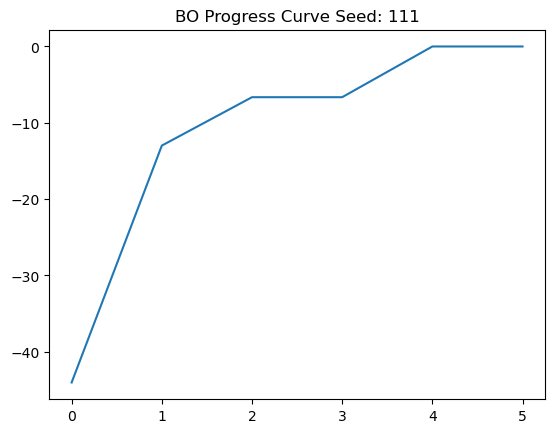

In [39]:
plt.plot(list(range(len(best))),best)
plt.title(f'BO Progress Curve Seed: {seed}')

## seeds

In [36]:
def plot_model_EIsimple(model,acqf,iter_no):
    fig,axis = plt.subplots(2, 1, figsize=(6,4), gridspec_kw={'hspace': 0.5, 'wspace': 0.3})
    x_domain = torch.linspace(lower, upper, 100).unsqueeze(-1).to(torch.double)

    post_at_x_domain = model.posterior(x_domain)
    mean_at_x_domain = post_at_x_domain.mean
    std_at_x_domain = torch.sqrt(post_at_x_domain.variance)
    lo_at_x_domain = mean_at_x_domain-1.96*std_at_x_domain
    up_at_x_domain = mean_at_x_domain+1.96*std_at_x_domain
    # count_idx = 0
    # for i in range(5):
    #     for j in range(2):
    #         axis[i,j].set_title(plot_name[count_idx])
    #         axis[i,j].plot(x,y[...,count_idx].detach().numpy(),marker='*', linestyle='none', markersize=10, color='black')
    #         axis[i,j].plot(x_domain,mean_at_x_domain[...,count_idx].detach().numpy(),color='blue',linewidth=2,label='Prediction')
    #         axis[i,j].fill_between(x_domain.squeeze(-1),lo_at_x_domain[...,count_idx].detach().numpy(),up_at_x_domain[...,count_idx].detach().numpy(),alpha=0.2,color='blue',label='Uncertainty')
    #         axis[i,j].legend()
    #         count_idx+=1
    inner_sample = IIDNormalSampler(sample_shape=torch.Size([2048])) #define based sample
    samples = inner_sample(post_at_x_domain) # do the sample
    samples_obj = g(samples)
    samplesmedian,_ = samples_obj.median(dim=0)
    samples025 = samples_obj.quantile(q=0.25,dim=0)
    samples0975 = samples_obj.quantile(q=0.975,dim=0)
    axis[0].set_title('Objective')
    axis[0].plot(x,g(y).squeeze(0).detach().numpy(),marker='*', linestyle='none', markersize=10, color='black')
    axis[0].plot(x_domain,samplesmedian.detach().numpy(),color='red',linewidth=2,label='Prediction')
    axis[0].fill_between(x_domain.squeeze(-1),samples025.detach().numpy(),samples0975.detach().numpy(),alpha=0.2,color='red',label='Uncertainty')
    axis[0].legend()
    #count_idx+=1
    acqf_val = acqf(x_domain.unsqueeze(-1))
    axis[1].set_title('EI')
    axis[1].plot(x_domain,acqf_val.detach().numpy(),color='green',label='EI')
    axis[1].plot(new_point.detach().numpy(),new_point_EI.detach().numpy(),marker='*',linestyle='none', markersize=10, color='yellow',label='Candidate')
    axis[1].legend()
    plt.suptitle(f"Iteration {iter_no}", fontsize=12, y=0.91)  # Reduce `y` to bring closer
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust subplot grid to fit universal title
    plt.show()


---------Seed: 0---------
Best value (thickness,tilt,obj) found: 242.8025245666504 , 6.332715928554535
Best value found: -44.87051773071289
new_point_EI val: 33.075
new_point_EI val: 15.554
new_point_EI val: 5.8065
new_point_EI val: 2.7895
new_point_EI val: 1.1742
new_point_EI val: 0.59544
new_point_EI val: 0.45358
new_point_EI val: 0.16266
new_point_EI val: 0.093872
new_point_EI val: 0.068036
new_point_EI val: 0.00055616
new_point_EI val: 0.0
new_point_EI val: 0.086297
new_point_EI val: 0.066591
new_point_EI val: 0.048338
new_point_EI val: 0.005061
new_point_EI val: 0.032303
new_point_EI val: 0.04398
new_point_EI val: 0.038195
new_point_EI val: 0.034005
Seed 0: Best obj -0.0 from iteration # 7 at x of 255.9630126953125 and 4.093667507171631


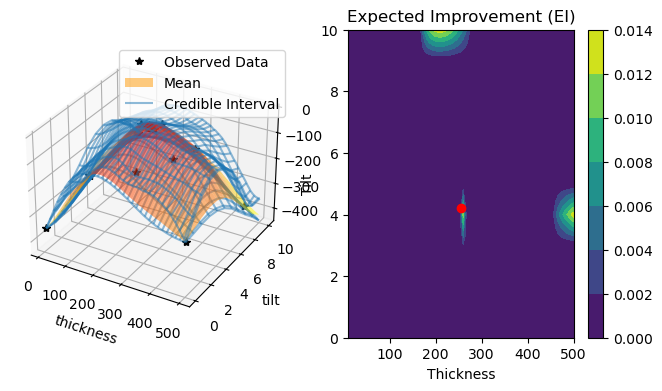

Time elapsed (hh:mm:ss.ms):  0:01:09.475626 


---------Seed: 1---------
Best value (thickness,tilt,obj) found: 328.46445386298 , 2.1474995091557503
Best value found: -55.12577438354492
new_point_EI val: 46.982
new_point_EI val: 28.453
new_point_EI val: 7.3924
new_point_EI val: 4.7715
new_point_EI val: 4.301
new_point_EI val: 4.3719
new_point_EI val: 1.2914
new_point_EI val: 0.60829
new_point_EI val: 0.11563
new_point_EI val: 0.094702
new_point_EI val: 0.092666
new_point_EI val: 0.065278
new_point_EI val: 0.051837
new_point_EI val: 0.043629
new_point_EI val: 0.037874
new_point_EI val: 0.033627
new_point_EI val: 0.040558
new_point_EI val: 0.030485
new_point_EI val: 0.0
new_point_EI val: 0.029046
Seed 1: Best obj -0.0 from iteration # 11 at x of 257.2087707519531 and 4.474063873291016


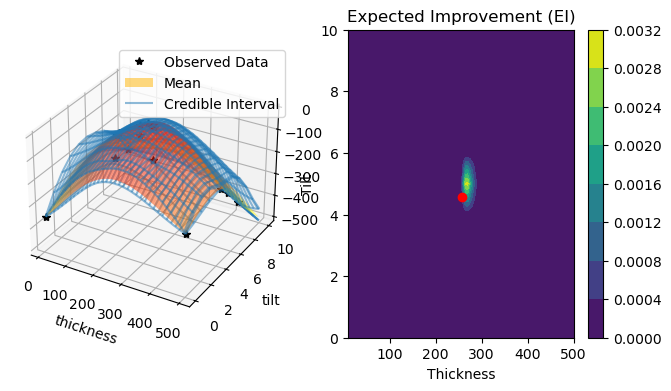

Time elapsed (hh:mm:ss.ms):  0:01:57.303253 


---------Seed: 2---------
Best value (thickness,tilt,obj) found: 370.0899780727923 , 4.746861164458096
Best value found: -69.673828125
new_point_EI val: 50.106
new_point_EI val: 26.838
new_point_EI val: 14.062
new_point_EI val: 6.4157
new_point_EI val: 5.8123
new_point_EI val: 1.9114
new_point_EI val: 1.497
new_point_EI val: 2.0953
new_point_EI val: 1.205
new_point_EI val: 1.2981
new_point_EI val: 0.96628
new_point_EI val: 0.072379
new_point_EI val: 0.0
new_point_EI val: 0.2237
new_point_EI val: 0.0
new_point_EI val: 0.12132
new_point_EI val: 0.0061112
new_point_EI val: 0.0
new_point_EI val: 0.032817
new_point_EI val: 0.052051
Seed 2: Best obj -0.0 from iteration # 10 at x of 258.1053161621094 and 4.3825483322143555


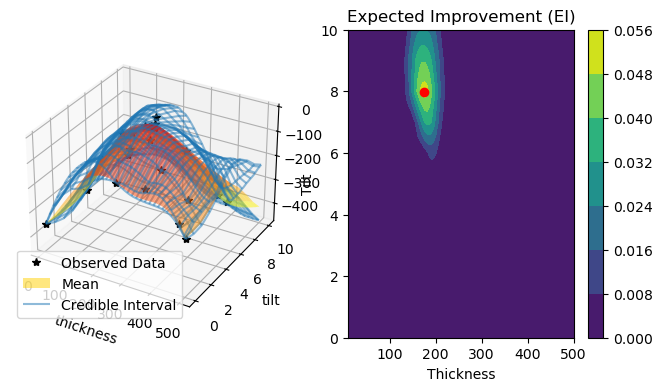

Time elapsed (hh:mm:ss.ms):  0:00:57.209866 


---------Seed: 3---------
Best value (thickness,tilt,obj) found: 314.5278227329254 , 7.507756016217172
Best value found: -140.38650512695312
new_point_EI val: 10.897
new_point_EI val: 12.801
new_point_EI val: 16.47
new_point_EI val: 6.8751
new_point_EI val: 2.4232
new_point_EI val: 1.0098
new_point_EI val: 1.0993
new_point_EI val: 0.74248
new_point_EI val: 0.54811
new_point_EI val: 0.036854
new_point_EI val: 0.028508
new_point_EI val: 0.022816
new_point_EI val: 0.059726
new_point_EI val: 0.02273
new_point_EI val: 0.020095
new_point_EI val: 0.018946
new_point_EI val: 0.0
new_point_EI val: 0.022252
new_point_EI val: 0.0
new_point_EI val: 0.028482
Seed 3: Best obj -0.0 from iteration # 12 at x of 254.2853240966797 and 4.422772407531738


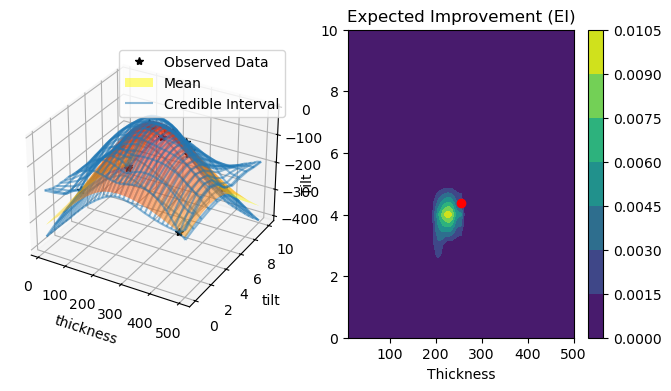

Time elapsed (hh:mm:ss.ms):  0:01:53.916593 


---------Seed: 4---------
Best value (thickness,tilt,obj) found: 231.08949500136077 , 2.6428022859618068
Best value found: -36.73118209838867
new_point_EI val: 11.355
new_point_EI val: 6.5599
new_point_EI val: 4.1849
new_point_EI val: 1.9355
new_point_EI val: 0.96229
new_point_EI val: 0.73052
new_point_EI val: 0.32976
new_point_EI val: 0.27602
new_point_EI val: 1.1859
new_point_EI val: 1.0455
new_point_EI val: 2.0555
new_point_EI val: 0.62363
new_point_EI val: 0.32018
new_point_EI val: 0.51979
new_point_EI val: 0.32447
new_point_EI val: 0.11016
new_point_EI val: 1.3117
new_point_EI val: 0.49193
new_point_EI val: 0.5523
new_point_EI val: 0.12094
Seed 4: Best obj -0.0 from iteration # 7 at x of 252.29725646972656 and 4.737926006317139


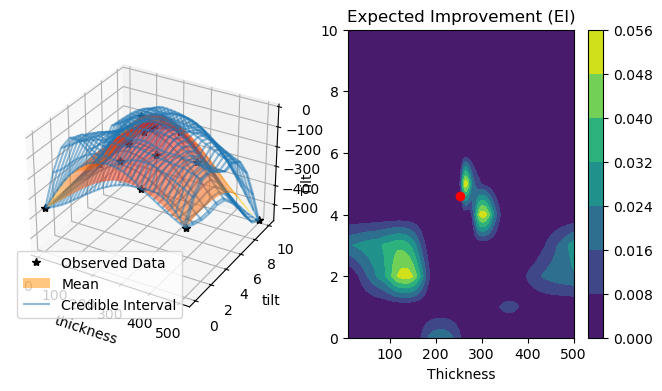

Time elapsed (hh:mm:ss.ms):  0:03:09.115804 


---------Seed: 5---------
Best value (thickness,tilt,obj) found: 323.8072201889008 , 3.9451777320355177
Best value found: -30.36528778076172
new_point_EI val: 27.526
new_point_EI val: 22.411
new_point_EI val: 9.8851
new_point_EI val: 11.921
new_point_EI val: 7.3348
new_point_EI val: 3.5015
new_point_EI val: 1.9565
new_point_EI val: 0.99148
new_point_EI val: 0.7016
new_point_EI val: 0.37458
new_point_EI val: 0.22047
new_point_EI val: 0.2034
new_point_EI val: 0.10412
new_point_EI val: 0.28612
new_point_EI val: 0.29696
new_point_EI val: 0.13071
new_point_EI val: 0.16177
new_point_EI val: 0.0
new_point_EI val: 2.8532
new_point_EI val: 0.61711
Seed 5: Best obj -0.0 from iteration # 9 at x of 256.46697998046875 and 4.469586372375488


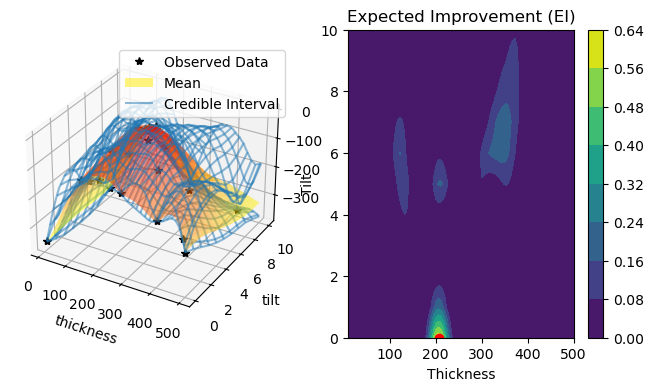

Time elapsed (hh:mm:ss.ms):  0:02:16.343233 


---------Seed: 6---------
Best value (thickness,tilt,obj) found: 347.9362976551056 , 3.504084050655365
Best value found: -38.366676330566406
new_point_EI val: 37.457
new_point_EI val: 19.006
new_point_EI val: 12.256
new_point_EI val: 6.6368
new_point_EI val: 3.8928
new_point_EI val: 2.3366
new_point_EI val: 2.1746
new_point_EI val: 0.32198
new_point_EI val: 0.090542
new_point_EI val: 1.166
new_point_EI val: 0.76459
new_point_EI val: 1.1678
new_point_EI val: 0.62304
new_point_EI val: 0.75263
new_point_EI val: 0.47878
new_point_EI val: 0.17748
new_point_EI val: 0.091352
new_point_EI val: 0.067001
new_point_EI val: 0.015791
new_point_EI val: 0.0013272
Seed 6: Best obj -0.0 from iteration # 12 at x of 258.05963134765625 and 4.391442775726318


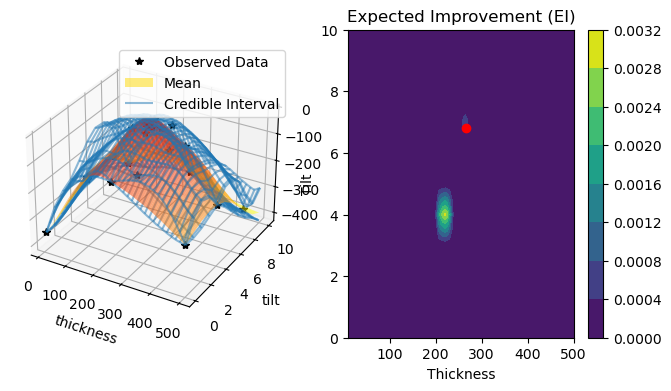

Time elapsed (hh:mm:ss.ms):  0:02:48.827948 


---------Seed: 7---------
Best value (thickness,tilt,obj) found: 328.25930441729724 , 5.352662721648812
Best value found: -36.20764923095703
new_point_EI val: 47.883
new_point_EI val: 25.875
new_point_EI val: 12.214
new_point_EI val: 12.819
new_point_EI val: 5.5668
new_point_EI val: 4.5468
new_point_EI val: 3.9008
new_point_EI val: 2.2069
new_point_EI val: 4.0936
new_point_EI val: 3.1841
new_point_EI val: 2.7999
new_point_EI val: 5.3403
new_point_EI val: 1.2584
new_point_EI val: 0.9576
new_point_EI val: 0.82401
new_point_EI val: 0.63447
new_point_EI val: 3.8383
new_point_EI val: 1.4306
new_point_EI val: 0.51125
new_point_EI val: 0.090533
Seed 7: Best obj -0.0 from iteration # 21 at x of 256.60986328125 and 4.438398838043213


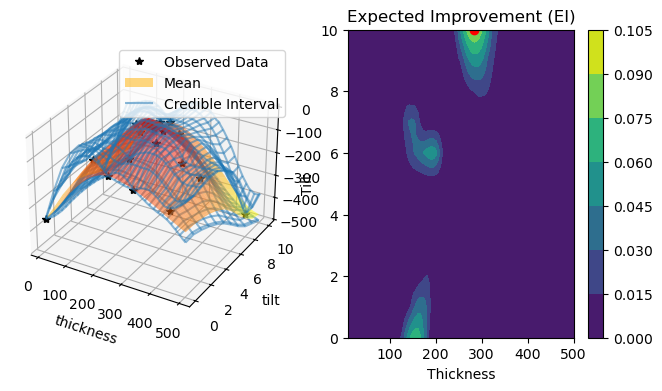

Time elapsed (hh:mm:ss.ms):  0:03:11.760719 


---------Seed: 8---------
Best value (thickness,tilt,obj) found: 277.8148329257965 , 4.7874743938446045
Best value found: -3.1052095890045166
new_point_EI val: 36.152
new_point_EI val: 22.779
new_point_EI val: 14.962
new_point_EI val: 8.7125
new_point_EI val: 8.0457
new_point_EI val: 2.3036
new_point_EI val: 1.6573
new_point_EI val: 1.2574
new_point_EI val: 0.68793
new_point_EI val: 0.57055
new_point_EI val: 0.20722
new_point_EI val: 0.03604
new_point_EI val: 0.070099
new_point_EI val: 0.12619
new_point_EI val: 0.041881
new_point_EI val: 0.18246
new_point_EI val: 0.21384
new_point_EI val: 0.17507
new_point_EI val: 0.054484
new_point_EI val: 0.076802
Seed 8: Best obj -0.0 from iteration # 8 at x of 255.07546997070312 and 4.433958530426025


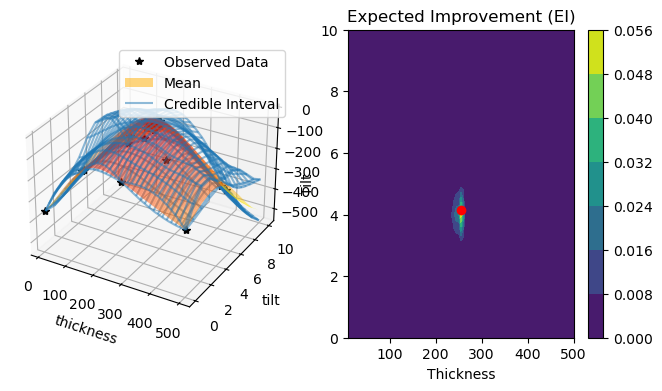

Time elapsed (hh:mm:ss.ms):  0:01:17.861717 


---------Seed: 9---------
Best value (thickness,tilt,obj) found: 271.2269192934036 , 3.0883572101593018
Best value found: -14.129439353942871
new_point_EI val: 35.787
new_point_EI val: 20.075
new_point_EI val: 12.248
new_point_EI val: 6.1443
new_point_EI val: 8.2677
new_point_EI val: 4.9973
new_point_EI val: 6.2115
new_point_EI val: 3.6868
new_point_EI val: 3.3423
new_point_EI val: 4.9574
new_point_EI val: 1.2179
new_point_EI val: 1.2002
new_point_EI val: 2.1615
new_point_EI val: 1.0992
new_point_EI val: 0.61312
new_point_EI val: 0.19447
new_point_EI val: 0.045648
new_point_EI val: 0.18231
new_point_EI val: 11.292
new_point_EI val: 8.0557
Seed 9: Best obj -0.0 from iteration # 5 at x of 254.93946838378906 and 4.170616149902344


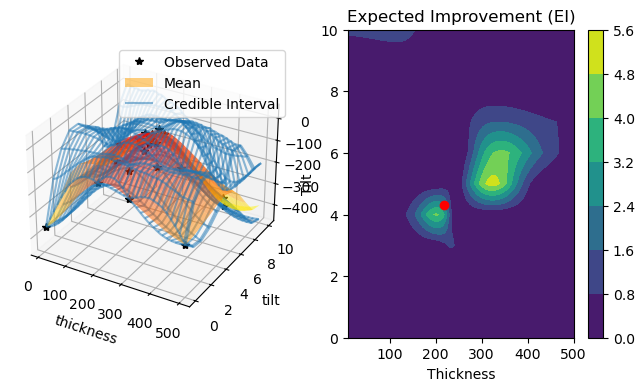

Time elapsed (hh:mm:ss.ms):  0:31:44.265014 


---------Seed: 10---------
Best value (thickness,tilt,obj) found: 302.50095484778285 , 2.927424375899136
Best value found: -48.52640914916992
new_point_EI val: 28.495
new_point_EI val: 17.952
new_point_EI val: 18.959
new_point_EI val: 5.8195
new_point_EI val: 4.1886
new_point_EI val: 2.5999
new_point_EI val: 2.1773
new_point_EI val: 1.4568
new_point_EI val: 0.29684
new_point_EI val: 1.3755
new_point_EI val: 1.1275
new_point_EI val: 0.87306
new_point_EI val: 1.1653
new_point_EI val: 0.31111
new_point_EI val: 0.11436
new_point_EI val: 0.076949
new_point_EI val: 0.19324
new_point_EI val: 0.083044
new_point_EI val: 0.0
new_point_EI val: 0.05013
Seed 10: Best obj -0.0 from iteration # 8 at x of 250.71751403808594 and 4.54407262802124


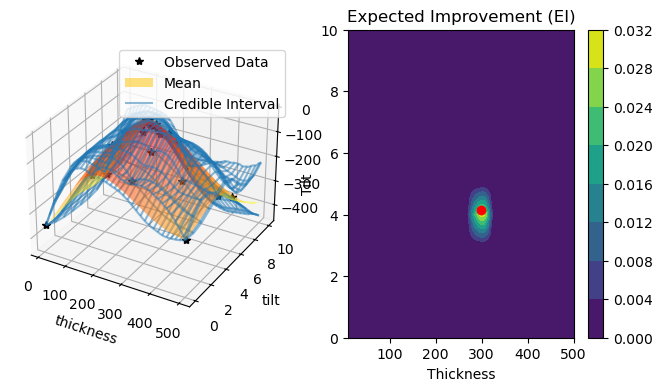

Time elapsed (hh:mm:ss.ms):  0:02:15.113094 


---------Seed: 11---------
Best value (thickness,tilt,obj) found: 155.35889606922865 , 3.3345101699233055
Best value found: -69.63997650146484
new_point_EI val: 21.461
new_point_EI val: 9.3553
new_point_EI val: 26.033
new_point_EI val: 6.5247
new_point_EI val: 3.2414
new_point_EI val: 1.5287
new_point_EI val: 0.1281
new_point_EI val: 0.4512
new_point_EI val: 0.31192
new_point_EI val: 0.61084
new_point_EI val: 0.28257
new_point_EI val: 0.16838
new_point_EI val: 0.04605
new_point_EI val: 0.0099509
new_point_EI val: 0.10075
new_point_EI val: 0.07426
new_point_EI val: 0.012494
new_point_EI val: 0.069025
new_point_EI val: 0.0
new_point_EI val: 0.0
Seed 11: Best obj -0.0 from iteration # 9 at x of 255.176513671875 and 4.0803022384643555


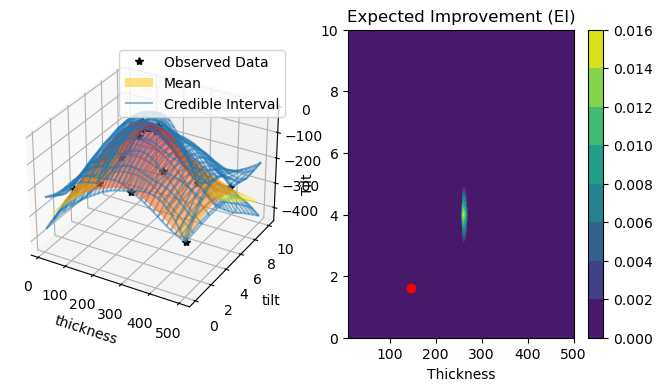

Time elapsed (hh:mm:ss.ms):  0:02:20.107969 


---------Seed: 12---------
Best value (thickness,tilt,obj) found: 367.58854770101607 , 2.545455927029252
Best value found: -74.69441986083984
new_point_EI val: 28.259
new_point_EI val: 19.657
new_point_EI val: 18.088
new_point_EI val: 4.9201
new_point_EI val: 3.0342
new_point_EI val: 2.0164
new_point_EI val: 1.177
new_point_EI val: 1.0723
new_point_EI val: 1.6372
new_point_EI val: 0.84729
new_point_EI val: 0.31938
new_point_EI val: 0.09164
new_point_EI val: 0.05799
new_point_EI val: 0.19352
new_point_EI val: 0.13135
new_point_EI val: 0.019215
new_point_EI val: 0.08917
new_point_EI val: 0.010412
new_point_EI val: 0.066313
new_point_EI val: 0.051849
Seed 12: Best obj -0.0 from iteration # 13 at x of 252.95272827148438 and 4.689969539642334


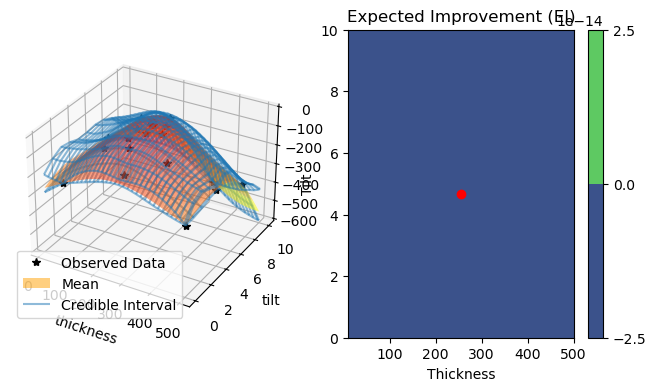

Time elapsed (hh:mm:ss.ms):  0:01:09.935498 


---------Seed: 13---------
Best value (thickness,tilt,obj) found: 263.6392269190401 , 5.843964254483581
Best value found: -12.986251831054688
new_point_EI val: 14.387
new_point_EI val: 12.677
new_point_EI val: 3.9048
new_point_EI val: 2.0456
new_point_EI val: 2.0624
new_point_EI val: 0.62357
new_point_EI val: 0.19974
new_point_EI val: 0.54484
new_point_EI val: 0.22637
new_point_EI val: 0.099014
new_point_EI val: 0.0
new_point_EI val: 18.762
new_point_EI val: 1.931
new_point_EI val: 0.32148
new_point_EI val: 0.13032
new_point_EI val: 17.89
new_point_EI val: 7.6064
new_point_EI val: 5.0606
new_point_EI val: 2.4005
new_point_EI val: 2.3558
Seed 13: Best obj -0.0 from iteration # 4 at x of 258.23809814453125 and 4.834720611572266


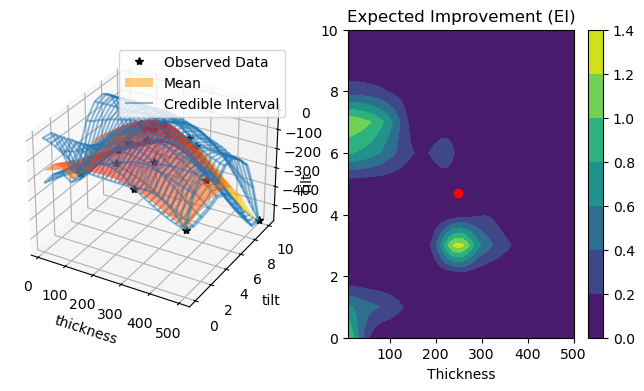

Time elapsed (hh:mm:ss.ms):  0:02:32.768806 


---------Seed: 14---------
Best value (thickness,tilt,obj) found: 294.20001190155745 , 4.443432263098657
Best value found: -10.05889892578125
new_point_EI val: 10.506
new_point_EI val: 8.2293
new_point_EI val: 3.5142
new_point_EI val: 2.5299
new_point_EI val: 3.8452
new_point_EI val: 1.3137
new_point_EI val: 0.78472
new_point_EI val: 2.6827
new_point_EI val: 2.9623
new_point_EI val: 1.3444
new_point_EI val: 2.1914
new_point_EI val: 4.9259
new_point_EI val: 1.0868
new_point_EI val: 0.8234
new_point_EI val: 0.81648
new_point_EI val: 0.11972
new_point_EI val: 0.11684
new_point_EI val: 0.099057
new_point_EI val: 0.17222
new_point_EI val: 0.16911
Seed 14: Best obj -0.0 from iteration # 18 at x of 254.20298767089844 and 4.492417812347412


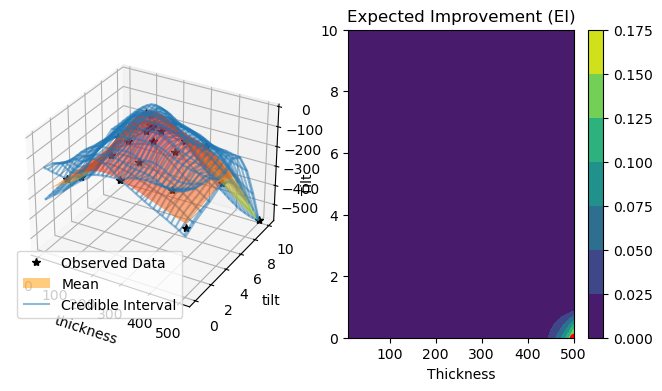

Time elapsed (hh:mm:ss.ms):  0:14:03.912133 


---------Seed: 15---------
Best value (thickness,tilt,obj) found: 190.997556746006 , 3.6074113249778748
Best value found: -36.00071716308594
new_point_EI val: 9.4783
new_point_EI val: 8.9602
new_point_EI val: 5.0174
new_point_EI val: 3.5779
new_point_EI val: 1.0055
new_point_EI val: 0.41703
new_point_EI val: 4.1149
new_point_EI val: 4.3586
new_point_EI val: 0.9466
new_point_EI val: 0.3966
new_point_EI val: 0.52114
new_point_EI val: 0.79415
new_point_EI val: 0.099769
new_point_EI val: 0.2613
new_point_EI val: 0.032046
new_point_EI val: 0.15918
new_point_EI val: 0.10823
new_point_EI val: 0.077133
new_point_EI val: 0.079288
new_point_EI val: 0.072997
Seed 15: Best obj -0.0 from iteration # 8 at x of 254.97653198242188 and 4.354865550994873


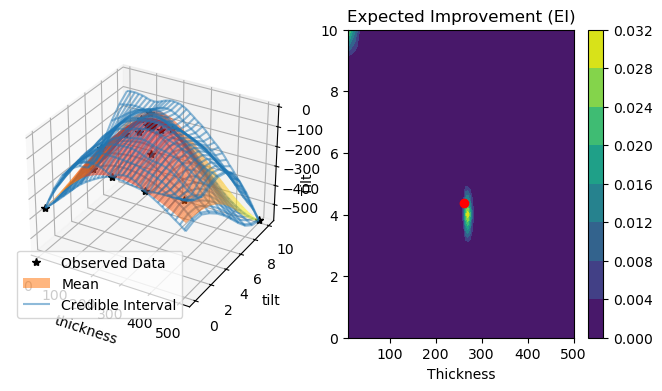

Time elapsed (hh:mm:ss.ms):  0:01:39.551932 


---------Seed: 16---------
Best value (thickness,tilt,obj) found: 145.3281749226153 , 3.8334503825753927
Best value found: -76.18787384033203
new_point_EI val: 22.611
new_point_EI val: 11.63
new_point_EI val: 15.632
new_point_EI val: 4.0808
new_point_EI val: 5.8563
new_point_EI val: 2.2747
new_point_EI val: 2.2355
new_point_EI val: 1.9286
new_point_EI val: 2.2855
new_point_EI val: 0.4255
new_point_EI val: 0.27859
new_point_EI val: 0.1849
new_point_EI val: 0.10361
new_point_EI val: 0.87435
new_point_EI val: 1.1025
new_point_EI val: 0.42922
new_point_EI val: 19.887
new_point_EI val: 9.8082
new_point_EI val: 14.484
new_point_EI val: 6.3849
Seed 16: Best obj -0.0 from iteration # 18 at x of 258.4374084472656 and 4.969511032104492


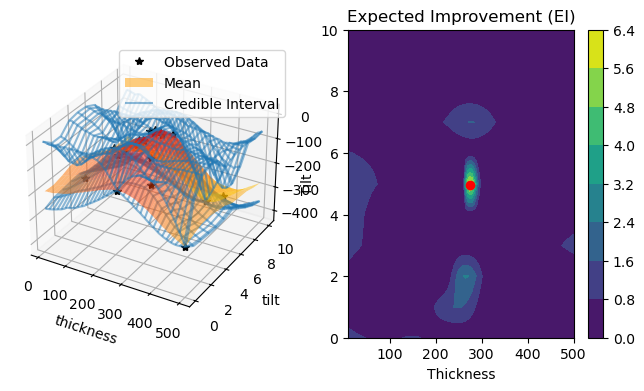

Time elapsed (hh:mm:ss.ms):  0:04:17.879567 


---------Seed: 17---------
Best value (thickness,tilt,obj) found: 200.9499115217477 , 5.736485775560141
Best value found: -21.921613693237305
new_point_EI val: 37.576
new_point_EI val: 14.736
new_point_EI val: 8.1076
new_point_EI val: 8.6384
new_point_EI val: 3.2158
new_point_EI val: 2.5852
new_point_EI val: 2.6695
new_point_EI val: 1.2847
new_point_EI val: 0.41747
new_point_EI val: 1.6282
new_point_EI val: 0.053993
new_point_EI val: 0.0
new_point_EI val: 0.12056
new_point_EI val: 0.064352
new_point_EI val: 0.047988
new_point_EI val: 0.03545
new_point_EI val: 0.030804
new_point_EI val: 0.0
new_point_EI val: 0.031242
new_point_EI val: 0.0
Seed 17: Best obj -0.0 from iteration # 13 at x of 252.17164611816406 and 4.571305751800537


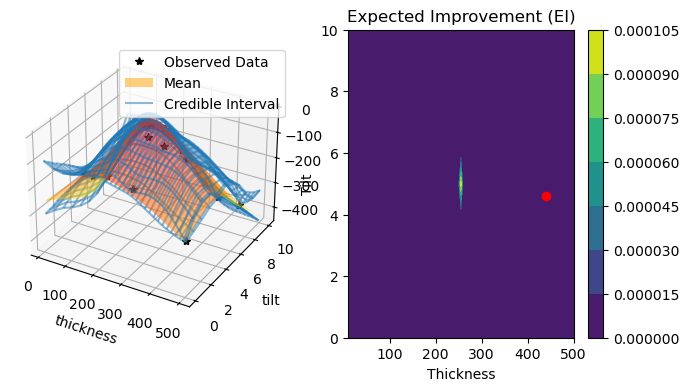

Time elapsed (hh:mm:ss.ms):  0:01:32.182258 


---------Seed: 18---------
Best value (thickness,tilt,obj) found: 239.76412038318813 , 3.087093537673354
Best value found: -14.096766471862793
new_point_EI val: 28.986
new_point_EI val: 17.163
new_point_EI val: 12.54
new_point_EI val: 17.665
new_point_EI val: 2.8091
new_point_EI val: 0.91601
new_point_EI val: 0.5343
new_point_EI val: 0.45686
new_point_EI val: 0.23515
new_point_EI val: 13.605
new_point_EI val: 4.7577
new_point_EI val: 3.4628
new_point_EI val: 5.5502
new_point_EI val: 3.3214
new_point_EI val: 4.0494
new_point_EI val: 1.6108
new_point_EI val: 1.3672
new_point_EI val: 1.8899
new_point_EI val: 4.8079
new_point_EI val: 2.0377
Seed 18: Best obj -0.0 from iteration # 7 at x of 254.77560424804688 and 4.186657428741455


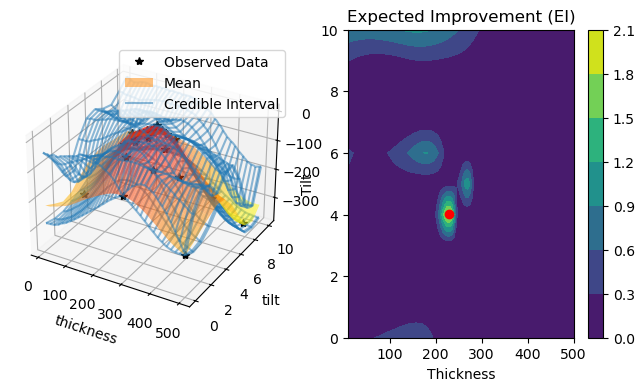

Time elapsed (hh:mm:ss.ms):  0:04:12.189822 


---------Seed: 19---------
Best value (thickness,tilt,obj) found: 143.175356592983 , 3.1461121775209904
Best value found: -76.18787384033203
new_point_EI val: 42.664
new_point_EI val: 25.02
new_point_EI val: 12.913
new_point_EI val: 6.9192
new_point_EI val: 3.5641
new_point_EI val: 2.6809
new_point_EI val: 0.42703
new_point_EI val: 0.43946
new_point_EI val: 1.0837
new_point_EI val: 1.1388
new_point_EI val: 0.67409
new_point_EI val: 0.80209
new_point_EI val: 0.9519
new_point_EI val: 0.58143
new_point_EI val: 0.16153
new_point_EI val: 0.093145
new_point_EI val: 0.064991
new_point_EI val: 0.084628
new_point_EI val: 0.027961
new_point_EI val: 0.058996
Seed 19: Best obj -0.0 from iteration # 9 at x of 258.9467468261719 and 4.382929801940918


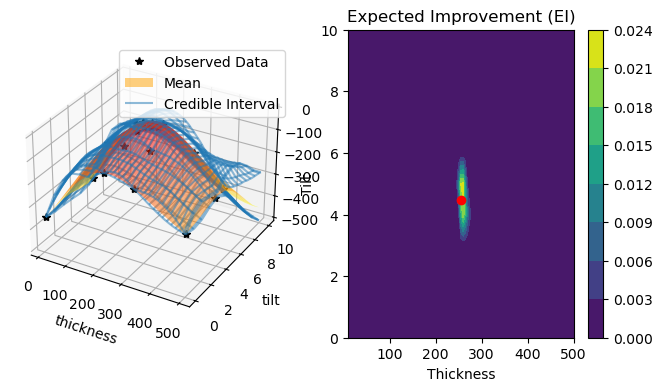

Time elapsed (hh:mm:ss.ms):  0:02:44.604984 


---------Seed: 20---------
Best value (thickness,tilt,obj) found: 218.2578887976706 , 7.798743197694421
Best value found: -84.3248519897461
new_point_EI val: 8.8026
new_point_EI val: 19.049
new_point_EI val: 14.817
new_point_EI val: 10.102
new_point_EI val: 8.8216
new_point_EI val: 7.3061
new_point_EI val: 3.8543
new_point_EI val: 3.9662
new_point_EI val: 1.2053
new_point_EI val: 0.81067
new_point_EI val: 0.36679
new_point_EI val: 0.16374
new_point_EI val: 0.22142
new_point_EI val: 0.20408
new_point_EI val: 3.5637
new_point_EI val: 5.0959
new_point_EI val: 2.7366
new_point_EI val: 0.84572
new_point_EI val: 0.71818
new_point_EI val: 0.43532
Seed 20: Best obj -0.0 from iteration # 16 at x of 254.8462677001953 and 4.257021427154541


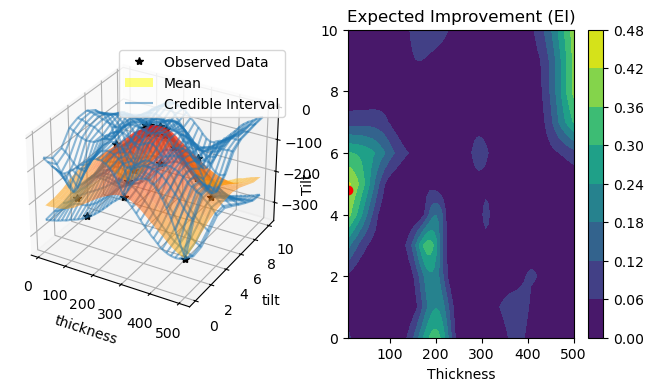

Time elapsed (hh:mm:ss.ms):  0:03:48.215696 


---------Seed: 21---------
Best value (thickness,tilt,obj) found: 133.41363072395325 , 1.6178443655371666
Best value found: -104.86181640625
new_point_EI val: 27.382
new_point_EI val: 14.851
new_point_EI val: 8.2831
new_point_EI val: 3.415
new_point_EI val: 2.4584
new_point_EI val: 1.5436
new_point_EI val: 0.66787
new_point_EI val: 0.43488
new_point_EI val: 0.22385
new_point_EI val: 0.088527
new_point_EI val: 0.11743
new_point_EI val: 0.013418
new_point_EI val: 1.0906
new_point_EI val: 0.087313
new_point_EI val: 0.068354
new_point_EI val: 0.0088249
new_point_EI val: 0.061101
new_point_EI val: 0.0
new_point_EI val: 0.0
new_point_EI val: 0.051964
Seed 21: Best obj -0.8404735922813416 from iteration # 9 at x of 261.1825256347656 and 4.61857795715332


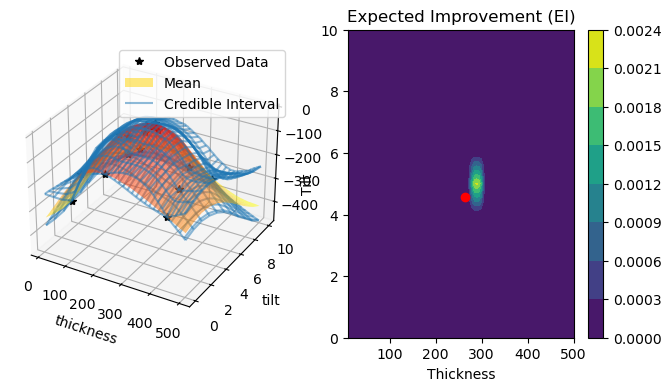

Time elapsed (hh:mm:ss.ms):  0:01:31.093316 


---------Seed: 22---------
Best value (thickness,tilt,obj) found: 349.96155574917793 , 2.2036777064204216
Best value found: -58.653228759765625
new_point_EI val: 14.636
new_point_EI val: 11.071
new_point_EI val: 6.4839
new_point_EI val: 3.4886
new_point_EI val: 3.3881
new_point_EI val: 3.847
new_point_EI val: 2.5656
new_point_EI val: 0.90151
new_point_EI val: 0.3735
new_point_EI val: 0.27214
new_point_EI val: 0.18175
new_point_EI val: 0.84085
new_point_EI val: 0.60486
new_point_EI val: 0.30167
new_point_EI val: 0.12457
new_point_EI val: 0.12272
new_point_EI val: 0.15339
new_point_EI val: 0.061719
new_point_EI val: 0.0
new_point_EI val: 0.16237
Seed 22: Best obj -0.0 from iteration # 14 at x of 255.64744567871094 and 4.6564130783081055


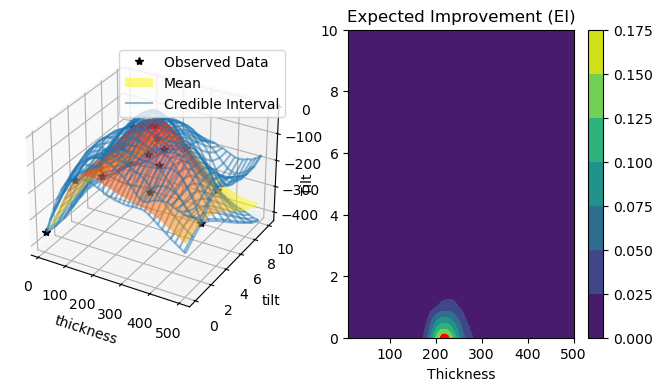

Time elapsed (hh:mm:ss.ms):  0:02:59.395468 


---------Seed: 23---------
Best value (thickness,tilt,obj) found: 212.5829952955246 , 2.340803027153015
Best value found: -41.40632247924805
new_point_EI val: 21.503
new_point_EI val: 15.969
new_point_EI val: 9.5723
new_point_EI val: 5.9736
new_point_EI val: 3.478
new_point_EI val: 1.4014
new_point_EI val: 0.81853
new_point_EI val: 0.55642
new_point_EI val: 0.21697
new_point_EI val: 0.14985
new_point_EI val: 0.1651
new_point_EI val: 0.20059
new_point_EI val: 2.5752
new_point_EI val: 0.85585
new_point_EI val: 0.089906
new_point_EI val: 0.1191
new_point_EI val: 0.10303
new_point_EI val: 0.088992
new_point_EI val: 0.0
new_point_EI val: 0.10895
Seed 23: Best obj -0.0 from iteration # 15 at x of 252.3349151611328 and 4.881284236907959


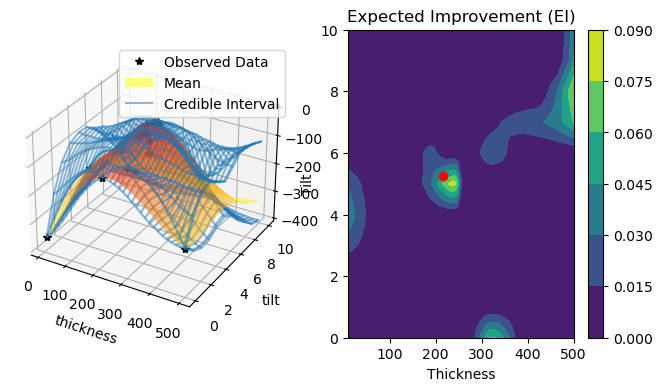

Time elapsed (hh:mm:ss.ms):  0:01:49.762901 


---------Seed: 24---------
Best value (thickness,tilt,obj) found: 162.33782469294965 , 7.5068520195782185
Best value found: -83.533935546875
new_point_EI val: 26.267
new_point_EI val: 21.526
new_point_EI val: 14.712
new_point_EI val: 9.2079
new_point_EI val: 4.8231
new_point_EI val: 2.9692
new_point_EI val: 1.5585
new_point_EI val: 1.1688
new_point_EI val: 0.74333
new_point_EI val: 1.0013
new_point_EI val: 0.53494
new_point_EI val: 0.20863
new_point_EI val: 0.59764
new_point_EI val: 0.29241
new_point_EI val: 0.38446
new_point_EI val: 0.14946
new_point_EI val: 0.099012
new_point_EI val: 0.074538
new_point_EI val: 0.055056
new_point_EI val: 0.073143
Seed 24: Best obj -0.0 from iteration # 10 at x of 259.254638671875 and 4.826859951019287


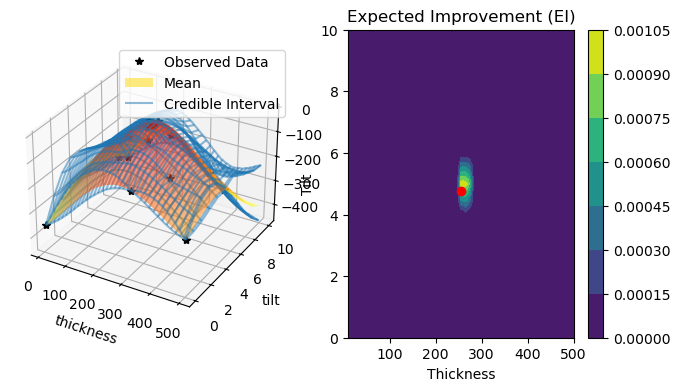

Time elapsed (hh:mm:ss.ms):  0:02:54.641287 


---------Seed: 25---------
Best value (thickness,tilt,obj) found: 298.9882745128125 , 5.5677946684882045
Best value found: -23.170995712280273
new_point_EI val: 23.017
new_point_EI val: 9.1652
new_point_EI val: 3.6727
new_point_EI val: 1.7243
new_point_EI val: 1.5679
new_point_EI val: 0.73617
new_point_EI val: 2.2108
new_point_EI val: 0.68492
new_point_EI val: 0.33556
new_point_EI val: 0.13433
new_point_EI val: 0.12324
new_point_EI val: 0.092396
new_point_EI val: 0.15477
new_point_EI val: 0.085098
new_point_EI val: 0.05905
new_point_EI val: 0.093932
new_point_EI val: 0.070384
new_point_EI val: 0.056997
new_point_EI val: 0.048196
new_point_EI val: 0.041919
Seed 25: Best obj -0.0 from iteration # 4 at x of 252.20872497558594 and 4.345551490783691


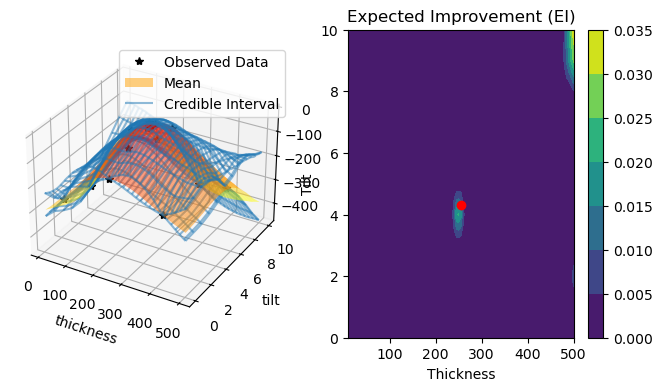

Time elapsed (hh:mm:ss.ms):  0:01:18.171816 


---------Seed: 26---------
Best value (thickness,tilt,obj) found: 313.58799991197884 , 2.227247324772179
Best value found: -50.67216873168945
new_point_EI val: 24.417
new_point_EI val: 19.094
new_point_EI val: 13.162
new_point_EI val: 9.9571
new_point_EI val: 3.6052
new_point_EI val: 2.2419
new_point_EI val: 0.50449
new_point_EI val: 1.0299
new_point_EI val: 0.84415
new_point_EI val: 0.4303
new_point_EI val: 0.34743
new_point_EI val: 0.19052
new_point_EI val: 2.6085
new_point_EI val: 1.2883
new_point_EI val: 0.37736
new_point_EI val: 0.15685
new_point_EI val: 1.4642
new_point_EI val: 0.95967
new_point_EI val: 0.088919
new_point_EI val: 0.36982
Seed 26: Best obj -0.0 from iteration # 11 at x of 250.9333953857422 and 4.645360946655273


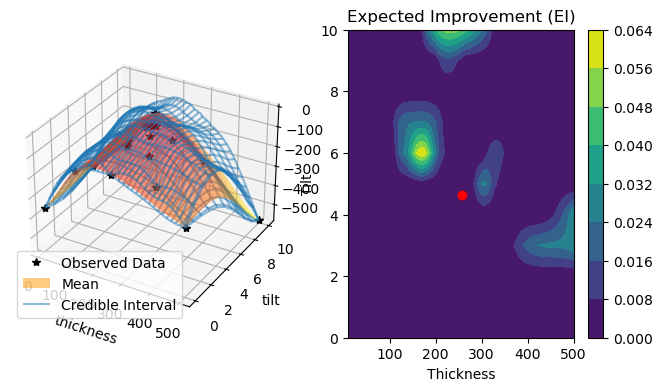

Time elapsed (hh:mm:ss.ms):  0:03:02.498344 


---------Seed: 27---------
Best value (thickness,tilt,obj) found: 314.476974606514 , 4.861614942550659
Best value found: -19.562274932861328
new_point_EI val: 29.61
new_point_EI val: 19.554
new_point_EI val: 10.417
new_point_EI val: 6.8908
new_point_EI val: 1.9225
new_point_EI val: 0.85407
new_point_EI val: 0.31691
new_point_EI val: 0.27055
new_point_EI val: 0.18651
new_point_EI val: 0.078878
new_point_EI val: 0.0075229
new_point_EI val: 0.59628
new_point_EI val: 0.12033
new_point_EI val: 0.05684
new_point_EI val: 0.025775
new_point_EI val: 0.070352
new_point_EI val: 0.0
new_point_EI val: 0.052336
new_point_EI val: 0.0
new_point_EI val: 0.043675
Seed 27: Best obj -0.0 from iteration # 5 at x of 256.4928894042969 and 4.095171928405762


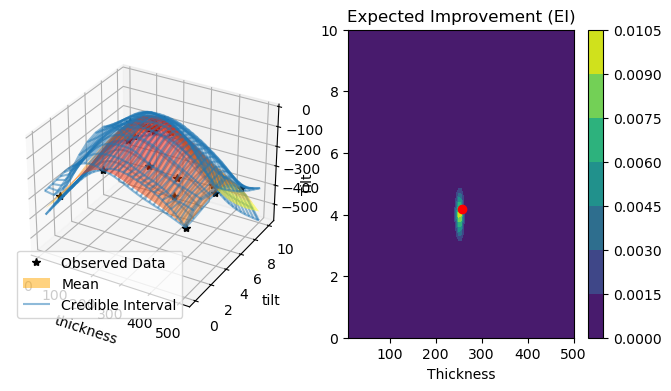

Time elapsed (hh:mm:ss.ms):  0:01:35.227675 


---------Seed: 28---------
Best value (thickness,tilt,obj) found: 291.61541163921356 , 4.539286375045776
Best value found: -10.05889892578125
new_point_EI val: 36.848
new_point_EI val: 21.504
new_point_EI val: 16.339
new_point_EI val: 7.1921
new_point_EI val: 4.0308
new_point_EI val: 2.5153
new_point_EI val: 1.2426
new_point_EI val: 0.61247
new_point_EI val: 0.073797
new_point_EI val: 0.26763
new_point_EI val: 0.042056
new_point_EI val: 0.11243
new_point_EI val: 0.10258
new_point_EI val: 0.08486
new_point_EI val: 0.010903
new_point_EI val: 0.058676
new_point_EI val: 0.047021
new_point_EI val: 0.0
new_point_EI val: 0.040649
new_point_EI val: 0.086344
Seed 28: Best obj -0.0 from iteration # 7 at x of 258.01043701171875 and 4.701107978820801


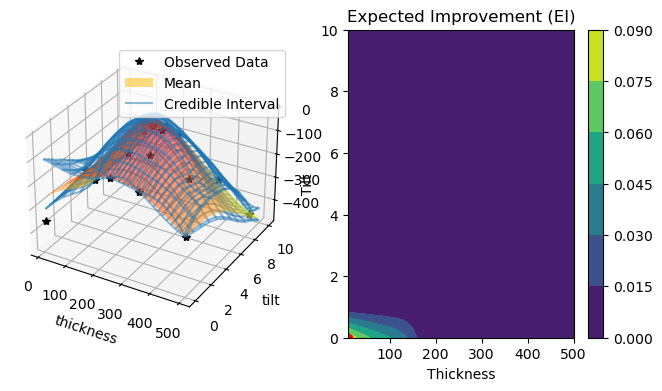

Time elapsed (hh:mm:ss.ms):  0:01:30.938885 


---------Seed: 29---------
Best value (thickness,tilt,obj) found: 261.355291120708 , 1.8288330789655447
Best value found: -70.20088958740234
new_point_EI val: 42.727
new_point_EI val: 21.076
new_point_EI val: 10.583
new_point_EI val: 4.5829
new_point_EI val: 3.8113
new_point_EI val: 2.1978
new_point_EI val: 0.90488
new_point_EI val: 0.17235
new_point_EI val: 0.0029045
new_point_EI val: 0.034925
new_point_EI val: 0.084057
new_point_EI val: 0.16219
new_point_EI val: 0.12919
new_point_EI val: 0.061458
new_point_EI val: 0.08926
new_point_EI val: 0.066995
new_point_EI val: 0.043463
new_point_EI val: 0.03445
new_point_EI val: 0.029175
new_point_EI val: 0.025615
Seed 29: Best obj -0.0 from iteration # 14 at x of 258.436279296875 and 4.369051933288574


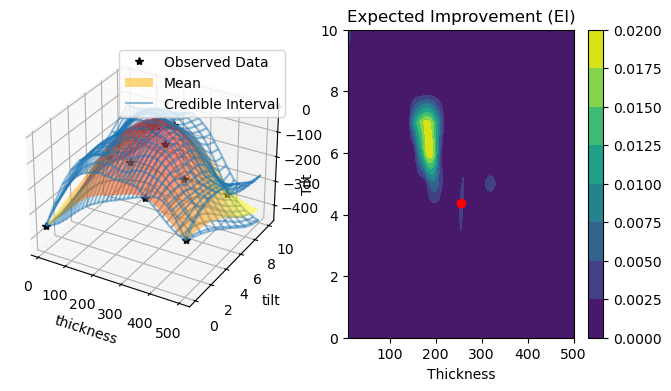

Time elapsed (hh:mm:ss.ms):  0:01:37.829139 



In [44]:
bestArr = []
xArr = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gridx1,gridx2 = torch.meshgrid(torch.linspace(lower,upper,101),torch.linspace(0,10,11))
    for seed in range(30):
        print('\n---------Seed: {}---------'.format(seed))
        start = datetime.now()
    
        np.random.seed(seed)
        torch.manual_seed(seed)
        random.seed(seed)

        n_initial_points = 4
        n_BO_points = 20

        # Generate initial data: several datapoints at random
        # Each one of them will be uniform between 0 and 3
        x,y,obj = generate_initial_data(n_initial_points=n_initial_points)
        g = GenericMCObjective(objective=lambda _y,**kwargs: - (torch.sum( (_y[...,:9]-torch.tensor(y_obsC[...,:9]).unsqueeze(0)).pow(2) , dim=-1)+_y[...,9]) )
        best = [obj.max().detach().item()] # This will store the best value
        best_x_idx = obj.argmax()
        print('Best value (thickness,tilt,obj) found: {} , {}'.format(x[best_x_idx,0].item(),
                                                              x[best_x_idx,1].item(),obj[best_x_idx]))
        print('Best value found: {}'.format(best[-1]))

        for i in range(n_BO_points): 
            # Fit the model
            noise = torch.ones_like(y) * 0.0001
            model = FixedNoiseGP(x, y, noise,outcome_transform=Standardize(m=10),input_transform=Normalize(d=2)) # GP is on y, not the objective
            # model = SingleTaskGP(x, y) # GP is on y, not the objective
            fit_gpytorch_model(ExactMarginalLogLikelihood(model.likelihood, model))
            #g = GenericMCObjective(objective=lambda _y: -(_y[:,:9]-torch.tensor(y_obsC[:9])).pow(2).mean(dim=-1) +_y[:,9] )
            #... for the batch. Whatever dimension in front then the dimension that i specify.
            #From 100 initial points, chooses 50 initial best points for the gradient descent
            best_obj = g(y).max() # same as -obj.min()
            sampler = SobolQMCNormalSampler(1024)
            EI = qExpectedImprovement(model=model, best_f=best_obj, objective=g,sampler=sampler)
            new_point, new_point_EI = optimize_acqf(
                acq_function=EI,
                bounds=torch.tensor([[lower,0], [upper,10]]).float(),
                q=1,
                num_restarts=50,
                raw_samples=100,
            )
            print(f"new_point_EI val: {new_point_EI:.5}")
                
            x,y,obj = add_dataC(new_point,x,y,obj)
            best.append(obj.max().item())
            best_x_idx = obj.argmax()
            
        print('Seed {}: Best obj {} from iteration # {} at x of {} and {}'.format(seed,
                                                                           obj.max(),
                                                                           best_x_idx,
                                                                           x[best_x_idx][0].item(),
                                                                                 x[best_x_idx][1].item()))

        # Plot the posterior and the EI
        f, (ax1,ax2) = plt.subplots(1, 2, figsize=(8, 4))
        
        # Plot the posterior
        ax1.axis('off')
        ax1 = plt.subplot(121, projection='3d') #row, col, index
        plot_posterior_composite(ax1,model,gridx1,gridx2,x,y)

        # Plot EI
        plotEI(ax2,gridx1,gridx2,EI,new_point)
        plt.show()
        
        #torch.cuda.synchronize()
        end = datetime.now()
        print('Time elapsed (hh:mm:ss.ms):  {} \n'.format(end-start))

        bestArr.append(best)
        xArr.append(x.squeeze().numpy())

### plot

In [45]:
bestArr = np.array(bestArr)
xArr = np.array(xArr)
np.savez('20250105-composite_initial4_1tilt.npz',bestArr=bestArr,xArr = xArr)

### composite seems to be much less dependent on initial points!

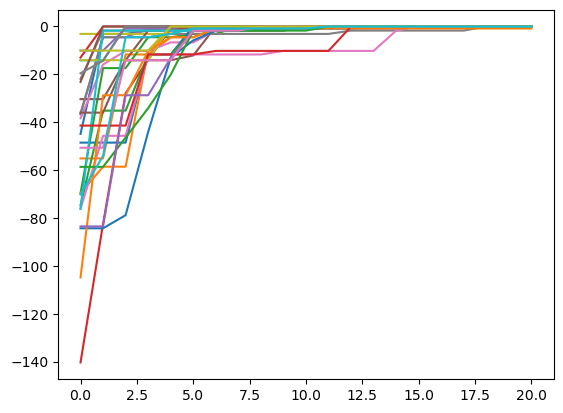

In [46]:
plt.figure()
plt.plot(bestArr.T);

In [47]:
bestAvg = np.mean(bestArr,axis=0)
bestStd = np.std(bestArr,axis=0)

Text(0, 0.5, 'Objective')

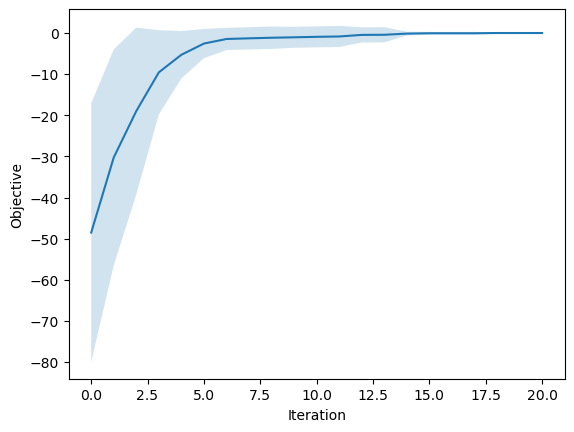

In [48]:
plt.figure()
plt.plot(bestAvg)
plt.fill_between(range(len(bestAvg)),bestAvg-bestStd,bestAvg+bestStd,alpha=0.2)
plt.xlabel('Iteration')
plt.ylabel('Objective')

## TODOs
20241204 <br>
- Evaluate the performance for x(thickness, tilt): is it worth using composite when tilt is added? What is the actual minimal cost of simulation? (e.g. ~4 seconds for classical BO vs. 30 sec - 1min for composite BO for 20 iterations/simulations)
- New simulated datasets. write a function to crop accordingly

## archive - other options
Plotting all 10 components

In [ ]:
x_domain = torch.linspace(lower, upper, 1000).unsqueeze(-1).to(torch.double)
def plot_model_EI(model,acqf,iter_no):
    fig,axis = plt.subplots(6, 2, figsize=(10, 15), gridspec_kw={'hspace': 0.5, 'wspace': 0.3})
    x_domain = torch.linspace(lower, upper, 1000).unsqueeze(-1).to(torch.double)

    post_at_x_domain = model.posterior(x_domain)
    mean_at_x_domain = post_at_x_domain.mean
    std_at_x_domain = torch.sqrt(post_at_x_domain.variance)
    lo_at_x_domain = mean_at_x_domain-1.96*std_at_x_domain
    up_at_x_domain = mean_at_x_domain+1.96*std_at_x_domain
    count_idx = 0
    for i in range(5):
        for j in range(2):
            axis[i,j].set_title(plot_name[count_idx])
            axis[i,j].plot(x,y[...,count_idx].detach().numpy(),marker='*', linestyle='none', markersize=10, color='black')
            axis[i,j].plot(x_domain,mean_at_x_domain[...,count_idx].detach().numpy(),color='blue',linewidth=2,label='Prediction')
            axis[i,j].fill_between(x_domain.squeeze(-1),lo_at_x_domain[...,count_idx].detach().numpy(),up_at_x_domain[...,count_idx].detach().numpy(),alpha=0.2,color='blue',label='Uncertainty')
            axis[i,j].legend()
            count_idx+=1
    inner_sample = IIDNormalSampler(sample_shape=torch.Size([2048])) #define based sample
    samples = inner_sample(post_at_x_domain) # do the sample
    samples_obj = g(samples)
    samplesmedian,_ = samples_obj.median(dim=0)
    samples025 = samples_obj.quantile(q=0.25,dim=0)
    samples0975 = samples_obj.quantile(q=0.975,dim=0)
    axis[5,0].set_title(plot_name[count_idx])
    axis[5,0].plot(x,g(y).squeeze(0).detach().numpy(),marker='*', linestyle='none', markersize=10, color='black')
    axis[5,0].plot(x_domain,samplesmedian.detach().numpy(),color='red',linewidth=2,label='Prediction')
    axis[5,0].fill_between(x_domain.squeeze(-1),samples025.detach().numpy(),samples0975.detach().numpy(),alpha=0.2,color='red',label='Uncertainty')
    axis[5,0].legend()
    count_idx+=1
    acqf_val = acqf(x_domain.unsqueeze(-1))
    axis[5,1].set_title(plot_name[count_idx])
    axis[5,1].plot(x_domain,acqf_val.detach().numpy(),color='green',label='EI')
    axis[5,1].plot(new_point.detach().numpy(),new_point_EI.detach().numpy(),marker='*',linestyle='none', markersize=10, color='yellow',label='Candidate')
    axis[5,1].legend()
    plt.suptitle(f"Iteration {iter_no}", fontsize=14, y=0.91)  # Reduce `y` to bring closer
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust subplot grid to fit universal title
    plt.show()